# Visualization Considerations Specific To Astronomy

##### Version 0.1

***

By Adam A Miller   
(Northwestern/CIERA/SkAI)  
24 August 2026

(plots made by Claude)

**Lecture summary and goals**

Everything we plot in astronomy has been through a chain of transformations: photons, to counts, to fluxes, to display values, to a sphere, to a flat page.

This lecture is about the decisions hiding in that chain, and about the fact that not making them is itself a decision.

I have previously told all of you that histograms are liars, but here's the thing...

Every astronomical image is a lie!

(This take may be too hot a few slides into the lecture...)

Like histograms, astronomical images are *estimators*. Detectors count photoelectrons, which is (somehow) converted to flux, which is converted to digital intensity, before being flattened to display on a screen. 

When you pick a projection, a bin size, a stretch, or a color channel, you are choosing an estimator.

Those choices can manufacture a signal (just as the choices for binning affects your histograms).

In this lecture we will work with simulated data $\longrightarrow$ thus we will know the ground truth (the problems will deal with real data). 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
from astropy.visualization import make_lupton_rgb

# Synthetic data for the demos below.
# Ships with the notebook; regenerate it by running Appendix A.1 + A.6.
_d = np.load('data/lecture_data.npz')
i_data, r_data, g_data = _d['i'], _d['r'], _d['g']
ra, dec = _d['ra'], _d['dec']

## Problem 1) Flat Earthers Rejoice (?)

The stars, galaxies, and solar systems that you care about live on the celestial sphere. 

The figures you make live on a flat screen.

(crap, crap, crap...)

Curvature is *intrinsic* to a surface, and a sphere has curvature while a plane does not.

Thus, there is no way to map from a sphere to a plane that preserves distances.

Mathematically this is not possible.

Thus, your projections onto a flat screen require a decision – **what lie do you want to tell**.

You can preserve *some* things, just never all of them:

$~~~$*Conformal* projections – preserve angles and local shapes (Mercator, gnomonic)

$~~~$*Equal-area* projections – preserve solid angle (Mollweide, Aitoff, Lambert)

$~~~$*Compromise* projections – preserve NOTHING, but the edge effects are not too wild (Robinson)

How do you tell which is which?

Draw circles of the same angular radius all over the sphere, and push them through the projection. Whatever happens to them happens to your data.

(This is [Tissot's indicatrix]().)

<img style="display: block; margin-left: auto; margin-right: auto" src="images/fig01_tissot.png" width="950" alt="Tissot indicatrix circles in plate carree, Mercator, Mollweide and Hammer, distorted differently in each" align="middle">

Mercator keeps every blob circular, but there are clear variations in area.

Mollweide and Hammer keep every blob the same area, but the circles don't look like circles away from the equator.

If you just want to throw `plt.scatter(ra, dec)` at your data, you get plate carrée, i.e., plain $x = \mathrm{RA}$, $y = \mathrm{Dec}$, which does not preserve area nor shape. 

How do these projections show stellar density maps?

<img style="display: block; margin-left: auto; margin-right: auto" src="./images/fig03_data_projections.png" width="900" alt="A simulated Milky Way catalogue rendered in plate carree, Mercator, Mollweide and Hammer, each giving the band a different shape" align="middle">

The choice of projection strongly affects what you can infer about the Milky Way.

The data are identical in all four panels. Only the projection (i.e., estimator) has changed.

So what choice should you make?

If you are plotting a density, use an equal-area projection.

Otherwise you are introducing a systematic error that traces the local density distortion.

This can easily be seen for an isotropic distribution of stars across the sky.

<img style="display: block; margin-left: auto; margin-right: auto" src="./images/fig02_equal_area.png" width="950" alt="An isotropic catalogue binned two ways; equal steps in declination show a false equatorial band" align="middle">

The left panel has a bright equatorial band and dark polar caps.

None of that is in the data.

A bin spanning $\Delta\mathrm{RA} \times \Delta\mathrm{Dec}$ subtends

$$\Omega = \Delta\mathrm{RA}\,\left[\sin(\mathrm{Dec}_2) - \sin(\mathrm{Dec}_1)\right]$$

which shrinks toward the poles. Smaller bins catch fewer objects.

Bin in $\sin(\mathrm{Dec})$ instead, and it goes away.

One projection deserves special mention, because it is the FITS default: gnomonic, or `TAN`.

Gnomonic maps great circles to straight lines, which is very nearly what a detector on a telescope does.

<img style="display: block; margin-left: auto; margin-right: auto" src="./images/fig05_gnomonic.png" width="900" alt="Gnomonic projection over a small field and a wide field, showing distortion growing rapidly with field size" align="middle">

Over one pointing, the distortion is negligible.

Over tens of degrees... woof.

The failure mode to watch for: someone fits a `TAN` WCS to a single field, then reuses it to plot an entire survey.

One last note on sky projections, 

RA is periodic. `matplotlib` does not know that.

<img style="display: block; margin-left: auto; margin-right: auto" src="./images/fig04_wrap.png" width="900" alt="A star cluster split across both edges of a plot by the right ascension wraparound, and the same cluster intact after wrapping" align="middle">

The visualization needs to have an "edge," which can introduce unusual structure.

Wrapping to $[-180, 180)$ fixes it – but notice what you just did.

You chose a central meridian.

Whether its on the Galactic center, your survey footprint, or $0^\mathrm{h}$ be mindful how you center your images. 

Also quietly at work in those sky maps: astronomical figures put north up and east to the **left**, because we look *out* at the sphere rather than *down* at it. Backwards from every terrestrial map you have ever seen.

A closing note on projections, do not show the entire sky if you do not need to:

<img style="display: block; margin-left: auto; margin-right: auto" src="./images/fig20_orthographic.png" width="1000" alt="The same catalogue in orthographic projection from three viewpoints, each showing only the visible hemisphere" align="middle">

Orthographic is the view from outside: a globe, showing one hemisphere.

It is not equal-area – it compresses hard toward the limb – so it is a poor choice for measuring a density.

But it is very good at *locating* things, because it looks like the sphere it came from.

## Problem 2) Pixels Aren't Just for Detectors

We just established that binning in RA and Dec invents structure.

So how should we create bins?

We want equal-area pixels, clean changes of resolution, and spherical harmonics that do not hurt.

(soft music plays in the distance...)

Enter HEALPix.

Hierarchical Equal Area isoLatitude Pixelization.

The name sorta says it all.

$~~~$*Equal area* – every pixel is the same solid angle

$~~~$*Iso-latitude* – pixel centers lie on rings, so SHTs are fast

$~~~$*Hierarchical* – each pixel splits into exactly four

<img style="display: block; margin-left: auto; margin-right: auto" src="./images/fig06_healpix_hierarchy.png" width="1000" alt="HEALPix tessellation of the sphere at NSIDE 1, 2 and 4, each pixel splitting into four" align="middle">

Every pixel has the same area, so pixel counts are densities. No correction factor.

Compare that against the rectangular binning that got us in trouble a moment ago.

<img style="display: block; margin-left: auto; margin-right: auto" src="./images/fig09_pixel_area.png" width="900" alt="Solid angle of rectangular right ascension and declination bins compared with uniform HEALPix pixel areas" align="middle">

The HEALPix resolution is set by `NSIDE`, always a power of two:

$$N_\mathrm{pix} = 12\,N_\mathrm{side}^2 \qquad \Omega_\mathrm{pix} \approx \frac{3438\ \mathrm{deg}^2}{N_\mathrm{side}^2}$$

| NSIDE | $N_\mathrm{pix}$ | pixel size |
|---|---|---|
| 64 | 49,152 | 55' |
| 256 | 786,432 | 14' |
| 1024 | 12.6 M | 3.4' |
| 4096 | 201 M | 51" |
| 16384 | 3.2 G | 13" |

Rubin-scale maps have a pixel size that is less than an arcminute.

Going from a catalog to a density map can be accomplished in three lines.

In [3]:
import healpy as hp

nside = 64
pix = hp.ang2pix(nside, ra, dec, lonlat=True)
density = np.bincount(pix, minlength=hp.nside2npix(nside))

That leaves choosing `NSIDE`, which is the bias-variance tradeoff wearing a spherical hat.

<img style="display: block; margin-left: auto; margin-right: auto" src="./images/fig08_nside_choice.png" width="1000" alt="A sky density map binned at NSIDE 8, 32 and 128, ranging from blocky to dominated by Poisson noise" align="middle">

Too coarse and you smooth away the thing you are trying to show.

Too fine and every pixel is a Poisson draw with $N \sim 2$.

A serviceable rule for a density map: aim for $\gtrsim 10$–$20$ objects per pixel.

Then the fractional noise is $\lesssim 30\%$, and you are not asking the reader's eye to average for you.

One more thing, because it confuses people every year:

HEALPix is a **pixelization**, not a projection.

You still have to project it to look at it. `hp.mollview` is quietly doing both.

#### Aside: `RING` vs `NESTED`

Not presented in the talk, but it is the detail most likely to cost you an afternoon.

HEALPix pixels can be numbered two ways. `RING` sweeps through iso-latitude rings from the north pole down. `NESTED` keeps each of the 12 base faces contiguous, so a pixel's four children are consecutive.

Read a map with the wrong one and you do not get an error. You get a map.

<img style="display: block; margin-left: auto; margin-right: auto" src="./images/fig07_ring_vs_nested.png" width="1000" alt="HEALPix pixel indices in RING and NESTED ordering, and a density map shredded into stripes by using the wrong ordering" align="middle">

On the right is a real density map, written `NESTED` and read back as `RING`. The Galaxy is still in there – every photon is accounted for – it has just been shredded into stripes.

If a HEALPix map ever looks like banded noise, check `nest=` before anything else.

## Problem 3) Why Don't We Just Show the Photons Directly?

Astronomical images (in the optical/IR) typically have an enormous dynamic range, but your screen is limited to 256 levels per channel.

<img style="display: block; margin-left: auto; margin-right: auto" src="./images/fig10_dynamic_range.png" width="950" alt="A star field displayed linearly and clipped, with a histogram showing pixel values spanning a factor of several hundred" align="middle">

This (simulated) field spans a factor of ~600. Real survey images span $10^5$–$10^6$.

A linear map shows you the bright stars *or* the sky. Never both.

Effective visualizations therefore require nonlinear transformations of the data.

There is no utility in an "unprocessed" image; all images have a chosen transformation. (but very few tell you which transformation has been made...)

The transformation can be described via two parameters:

$~~~$*The interval* – which input values map onto the display range?

$~~~$*The stretch* – how are values distributed *within* that range?

Start with the stretch. Same data, same interval, six different "views" of the sky.

<img style="display: block; margin-left: auto; margin-right: auto" src="./images/fig11_stretches.png" width="760" alt="The same image shown through linear, square root, power, log, arsinh and histogram equalisation stretches" align="middle">

Linear buries everything faint. Power-laws are even worse.

Log lifts faint structure but mushes the bright end, and misbehaves near the sky noise.

Histogram equalization is the interesting one.

It maximizes information transmitted per display level – and it is the most misleading of the set.

It destroys any sense of *relative* brightness. Two regions of equal display value need have nothing in common.

So we want something linear where the noise is, and logarithmic where the stars are.

$$\operatorname{arsinh} x = \ln\left(x + \sqrt{x^2 + 1}\right)$$

$$\operatorname{arsinh} x \approx x \quad (|x| \ll 1)$$

$$\operatorname{arsinh} x \approx \ln(2x) \quad (|x| \gg 1)$$

$\operatorname{arsinh}$ shows all the detail (stars and sky). 

<img style="display: block; margin-left: auto; margin-right: auto" src="./images/fig12_transfer.png" width="900" alt="Transfer function curves for linear, square root, log and arsinh stretches on linear and logarithmic axes" align="middle">

How should you choose limits after setting the stretch?

<img style="display: block; margin-left: auto; margin-right: auto" src="./images/fig13_intervals.png" width="1000" alt="The same image under one stretch with MinMax, two percentile intervals and ZScale limits" align="middle">

`MinMax` is essentially never right – one hot pixel sets your entire scale.

`ZScale`, inherited from IRAF, estimates the sky and its slope, and is well tuned for exactly this.

**Break out question 1**

What should be set first the stretch or the interval? 

*Take a minute to discuss with your partner*

## Problem 4) Does HST Really Tell You What the COSMOS Look Like?

I have told you before, and soon you'll be told again, that color is a *poor* choice for communicating quantitative information.

Non-monotonic, not perceptually uniform, and ~5% of your audience cannot read it as intended.

For astronomical images, however, color can make a huge difference.

Aesthetics have nothing to do with it! 

For astronomy color = physics, (e.g., temperature, redshift, extinction, emission lines)

Let's build a "false-color" image.

To display RGB with `imshow` in `matplotlib` we need an $M \times N \times 3$ array.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [105.251854..118970.11].


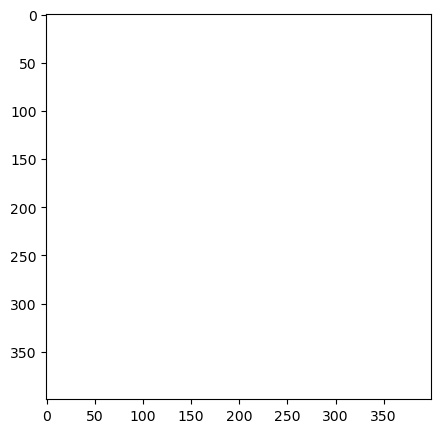

In [4]:
rgb = np.dstack((i_data, r_data, g_data))

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(rgb)

Every pixel clipped to 1, so the whole frame is white.

`matplotlib` warns rather than errors – RGB floats must lie in $[0, 1]$, and ours run to $\sim\!10^5$ counts.

That pink `Clipping input data to the valid range for imshow` box is expected, not a bug. It is `matplotlib` telling you that a scaling is required. 

So scale each band onto $[0, 1]$ and stack.

In [5]:
def scaled_intensity(R_array, G_array, B_array):
    '''Linearly scale three arrays from 0 ---> 1 and stack them'''
    out = []
    for arr in (R_array, G_array, B_array):
        a = np.asarray(arr, dtype=float)
        out.append((a - np.nanmin(a)) / (np.nanmax(a) - np.nanmin(a)))
    return np.dstack(out)


rgb = scaled_intensity(i_data - np.nanmedian(i_data),
                       r_data - np.nanmedian(r_data),
                       g_data - np.nanmedian(g_data))

Still nearly black – that is the dynamic range problem again, now in triplicate.

The obvious move is to stretch each band before stacking.

(Turns out the obvious move is a mistake...)

<img style="display: block; margin-left: auto; margin-right: auto" src="./images/fig14_naive_vs_lupton.png" width="1000" alt="Three colour renderings: linearly scaled and black, independently stretched with white saturated cores, and Lupton with colour preserved" align="middle">

Look at the galaxy core and the bright stars in the middle panel.

They have all gone **white**.

Here is why. If each band is normalized separately, then wherever all three bands are bright, all three get pushed toward 1.

And "all three channels near 1" *is* white.

So the brightest, most information-rich part of your image is exactly where we *lose* the color.

Color was the reason for attempting an RGB image in the first place.

[Lupton et al. (2004)](https://ui.adsabs.harvard.edu/abs/2004PASP..116..133L/abstract) fixed this for SDSS.

The insight: separate **brightness** from **color**, and stretch only the brightness.

Define an intensity in every pixel,

$$I \equiv (r + g + b)/3$$

then scale all three channels by the *same* factor:

$$R = r\,\frac{f(I)}{I}, \qquad G = g\,\frac{f(I)}{I}, \qquad B = b\,\frac{f(I)}{I}$$

Every channel is multiplied by the same number, so the **ratios** $r:g:b$ never move.

The stretch changes how bright a pixel looks. It cannot change its color.

The usual choice of scaling function is

$$f(I) = \frac{\operatorname{arsinh}\left(\alpha Q [I - m]\right)}{Q}$$

with $m$ the black point, and $Q$, $\alpha$ softening parameters.

Clipping channel-by-channel would re-introduce the white cores we just removed.

Low $Q$ is nearly linear. High $Q$ turns over early and pulls up faint structure hard.

Tuning is not cheating. But you have to **report the parameters**.

Could a reader pull the same data from the archive and reproduce your figure? If yes, it's processing. If no, it's painting.

**Breakout question 2**

Which band goes in which channel?

*Take a minute to discuss with your partner*

<img style="display: block; margin-left: auto; margin-right: auto" src="./images/fig16_channel_mapping.png" width="1000" alt="The same three bands assigned to red, green and blue channels in three different orders" align="middle">

Wavelength-ordered – longest to R, shortest to B – is the honest default.

But composite X-ray, radio, or mid-IR and there is no true color.

None of those panels is *wrong*. They just say different things.

Caption the band-to-channel mapping, every time.

"Red = 21 cm, green = H$\alpha$, blue = 0.5–2 keV" is one line, and without it your figure cannot be read.

## Conclusions

| step | your decision | how it bites |
|---|---|---|
| sphere $\to$ plane | projection | densities on a non-equal-area map |
| binning | pixelization, NSIDE | RA/Dec bins; Poisson noise as structure |
| counts $\to$ display | interval, stretch | one saturated star sets the scale |
| bands $\to$ channels | filter mapping | independent stretches whiten the core |

Not one of those steps has a default that is right for all images. 

So remember...

**Every figure is an estimate.** Projection, binning, stretch, channel mapping – these have the same standing as your choice of estimator.

**Report the transform.** If a reader with the archive data and your caption cannot reproduce your figure, it isn't a measurement.

#### Worry About the Data. Especially for astronmical images

**Further reading**

* Lupton et al. (2004), [*Preparing Red-Green-Blue Images from CCD Data*](https://ui.adsabs.harvard.edu/abs/2004PASP..116..133L/abstract)
* Górski et al. (2005), [*HEALPix*](https://ui.adsabs.harvard.edu/abs/2005ApJ...622..759G/abstract)
* Calabretta & Greisen (2002), [*Celestial coordinates in FITS*](https://ui.adsabs.harvard.edu/abs/2002A%26A...395.1077C/abstract)
* Alard & Lupton (1998), [*A Method for Optimal Image Subtraction*](https://ui.adsabs.harvard.edu/abs/1998ApJ...503..325A/abstract)
* Snyder (1987), *Map Projections: A Working Manual*, USGS PP 1395

# Appendix: Figure Generation

Every figure in this lecture is made by the code below, which writes PNGs into `images/`.

Nothing needs downloading – the generators in A.1 build the sky catalogs and the three-band imaging from scratch.

The notebook is self-contained: run A.1 through A.6 and every figure, plus the small data file the lecture body loads, is rebuilt from scratch.

**Requires:** `numpy`, `scipy`, `matplotlib`, `astropy`, `healpy` (Python 3.13).

### A.1 Common helpers and synthetic data

In [7]:
"""Common helpers and synthetic data for the lecture figures."""
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 110,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "image.origin": "lower",
    "image.interpolation": "nearest",
})

IMDIR = "images"
RNG_SEED = 20260813


def savefig(fig, name):
    import os
    os.makedirs(IMDIR, exist_ok=True)
    path = f"{IMDIR}/{name}.png"
    fig.savefig(path)
    plt.close(fig)
    print(f"wrote {path}")
    return path


# ----------------------------------------------------------------------
# Spherical geometry helpers
# ----------------------------------------------------------------------
def uniform_sphere(n, rng=None):
    """Draw n points uniformly on the sphere. Returns (ra, dec) in degrees."""
    rng = np.random.default_rng(RNG_SEED) if rng is None else rng
    ra = rng.uniform(0, 360, n)
    dec = np.degrees(np.arcsin(rng.uniform(-1, 1, n)))
    return ra, dec


def small_circle(lon0, lat0, radius, n=200):
    """Points on a geodesic circle of angular `radius` about (lon0, lat0).

    All arguments in degrees. This is what a Tissot indicatrix is made of:
    a circle that is genuinely circular *on the sphere*.
    """
    lon0, lat0, radius = np.radians([lon0, lat0, radius])
    theta = np.linspace(0, 2 * np.pi, n)
    lat = np.arcsin(np.sin(lat0) * np.cos(radius)
                    + np.cos(lat0) * np.sin(radius) * np.cos(theta))
    lon = lon0 + np.arctan2(np.sin(theta) * np.sin(radius) * np.cos(lat0),
                            np.cos(radius) - np.sin(lat0) * np.sin(lat))
    return np.degrees(lon), np.degrees(lat)


def wrap180(lon):
    """Wrap longitude to [-180, 180)."""
    return (np.asarray(lon) + 180) % 360 - 180


def radec_to_galactic(ra, dec):
    """Equatorial (ICRS) -> Galactic, in degrees. Uses astropy if available."""
    from astropy.coordinates import SkyCoord
    import astropy.units as u
    c = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs").galactic
    return c.l.deg, c.b.deg


def galactic_to_radec(l, b):
    from astropy.coordinates import SkyCoord
    import astropy.units as u
    c = SkyCoord(l=l * u.deg, b=b * u.deg, frame="galactic").icrs
    return c.ra.deg, c.dec.deg


def mock_galaxy_sky(n=200_000, rng=None):
    """A toy 'Milky Way plus isotropic background' catalogue.

    Two populations: a thin disk concentrated toward b = 0 with a bulge at
    the Galactic centre, plus an isotropic extragalactic component. Returned
    in equatorial coordinates so that the frame-choice figure has something
    honest to say.
    """
    rng = np.random.default_rng(RNG_SEED + 1) if rng is None else rng
    n_disk = int(0.75 * n)
    n_iso = n - n_disk

    # Disk: exponential in |b|, weighted toward the Galactic centre in l
    b = rng.laplace(0.0, 6.0, n_disk)
    b = np.clip(b, -90, 90)
    l = rng.normal(0.0, 55.0, n_disk)
    keep = rng.uniform(size=n_disk) < 0.55
    l[keep] = rng.uniform(-180, 180, keep.sum())
    l = wrap180(l)

    # Bulge
    n_bulge = n_disk // 6
    lb = rng.normal(0.0, 8.0, n_bulge)
    bb = rng.normal(0.0, 5.0, n_bulge)
    l = np.concatenate([l, lb])
    b = np.concatenate([b, bb])

    ra_d, dec_d = galactic_to_radec(l, b)
    ra_i, dec_i = uniform_sphere(n_iso, rng)
    ra = np.concatenate([ra_d, ra_i])
    dec = np.concatenate([dec_d, dec_i])
    return ra, dec


# ----------------------------------------------------------------------
# Synthetic imaging
# ----------------------------------------------------------------------
def _moffat(rr2, alpha, beta=3.0):
    return (1 + rr2 / alpha ** 2) ** (-beta)


def _sersic(rr, re, n_ser=1.0):
    bn = 2 * n_ser - 1 / 3
    return np.exp(-bn * ((rr / re) ** (1 / n_ser) - 1))


def synthetic_field(shape=(400, 400), seed=RNG_SEED, seeing=2.6,
                    band_gain=(1.0, 1.0, 1.0), sky=180.0, read_noise=6.0):
    """A synthetic star field with one bright spiral-ish galaxy.

    `band_gain` scales the three source classes (stars, galaxy, HII knots)
    so that the same scene can be rendered in three filters with genuinely
    different colours. Returns counts in ADU, including a sky pedestal.
    """
    rng = np.random.default_rng(seed)
    ny, nx = shape
    yy, xx = np.mgrid[0:ny, 0:nx].astype(float)
    img = np.zeros(shape, float)

    g_star, g_gal, g_knot = band_gain
    # A Moffat normalised to unit PEAK carries total flux ~ alpha^2, so a
    # change of seeing would change a star's brightness. Renormalise to a
    # reference seeing so that total flux is conserved instead.
    fnorm = (2.6 / seeing) ** 2

    # --- stars: power-law flux distribution, a few very bright ---
    n_star = 260
    sx = rng.uniform(0, nx, n_star)
    sy = rng.uniform(0, ny, n_star)
    flux = 60.0 * (rng.pareto(1.1, n_star) + 1) ** 1.0
    flux = np.clip(flux, 40, 4.0e4)
    # a handful of guaranteed bright stars so the dynamic range is real
    flux[:6] = np.array([9e4, 6e4, 4.2e4, 3.1e4, 2.4e4, 1.8e4])
    colour = rng.uniform(0.55, 1.6, n_star)  # star-to-star colour scatter
    for x0, y0, f, c in zip(sx, sy, flux, colour):
        rr2 = (xx - x0) ** 2 + (yy - y0) ** 2
        m = rr2 < (14 * seeing) ** 2
        img[m] += f * g_star * c ** (g_star - 1 + 0.0) * fnorm * _moffat(rr2[m], seeing)

    # --- galaxy: exponential disk + bulge, slightly inclined ---
    x0, y0 = 0.62 * nx, 0.40 * ny
    th = np.radians(35.0)
    xr = (xx - x0) * np.cos(th) + (yy - y0) * np.sin(th)
    yr = -(xx - x0) * np.sin(th) + (yy - y0) * np.cos(th)
    rr = np.sqrt(xr ** 2 + (yr / 0.55) ** 2)
    img += 900.0 * g_gal * _sersic(np.maximum(rr, 0.5), re=26.0, n_ser=1.0)
    rb = np.sqrt(xr ** 2 + yr ** 2)
    img += 5200.0 * g_gal * _sersic(np.maximum(rb, 0.6), re=4.5, n_ser=3.0)

    # --- star-forming knots in the disk: strong in the 'blue'/'Halpha' band ---
    n_knot = 22
    ang = rng.uniform(0, 2 * np.pi, n_knot)
    rad = rng.uniform(10, 46, n_knot)
    kx = x0 + rad * np.cos(ang) * np.cos(th) - 0.55 * rad * np.sin(ang) * np.sin(th)
    ky = y0 + rad * np.cos(ang) * np.sin(th) + 0.55 * rad * np.sin(ang) * np.cos(th)
    for x1, y1 in zip(kx, ky):
        rr2 = (xx - x1) ** 2 + (yy - y1) ** 2
        m = rr2 < (10 * seeing) ** 2
        img[m] += 420.0 * g_knot * fnorm * _moffat(rr2[m], seeing * 1.3)

    # --- faint background galaxies ---
    n_bg = 70
    for _ in range(n_bg):
        bx, by = rng.uniform(0, nx), rng.uniform(0, ny)
        re = rng.uniform(2.0, 6.0)
        amp = rng.uniform(15, 120) * g_gal
        rr2 = (xx - bx) ** 2 + (yy - by) ** 2
        m = rr2 < (10 * re) ** 2
        img[m] += amp * np.exp(-np.sqrt(np.maximum(rr2[m], 0.3)) / re)

    # --- sky + noise ---
    img += sky
    img = rng.poisson(np.clip(img, 0, None)).astype(float)
    img += rng.normal(0, read_noise, shape)
    return img


def three_band_field(shape=(400, 400), seed=RNG_SEED):
    """Return (i, r, g) synthetic images of the same scene.

    The galaxy is red, the HII knots are blue-green, and the stars span a
    range of colours -- i.e. there is genuine colour information to preserve
    or destroy.
    """
    i_img = synthetic_field(shape, seed=seed, seeing=2.6,
                            band_gain=(1.00, 1.35, 0.55), sky=190.0)
    r_img = synthetic_field(shape, seed=seed, seeing=2.8,
                            band_gain=(1.00, 1.00, 1.00), sky=175.0)
    g_img = synthetic_field(shape, seed=seed, seeing=3.1,
                            band_gain=(1.00, 0.62, 1.75), sky=165.0)
    return i_img, r_img, g_img

### A.2 Projections

In [8]:
"""Section 1 figures -- sphere to plane."""
import numpy as np
import matplotlib.pyplot as plt


# ----------------------------------------------------------------------
def _graticule(ax, proj, dlon=30, dlat=15, **kw):
    kw = dict(color="0.65", lw=0.5, zorder=1) | kw
    eps = 1e-6
    for lon in np.arange(-180, 181, dlon):
        lon = np.clip(lon, -180 + eps, 180 - eps)
        lat = np.linspace(-89.5, 89.5, 200)
        x, y = proj(np.full_like(lat, lon), lat)
        ax.plot(x, y, **kw)
    for lat in np.arange(-75, 76, dlat):
        lon = np.linspace(-180 + eps, 180 - eps, 400)
        x, y = proj(lon, np.full_like(lon, lat))
        ax.plot(x, y, **kw)


# --- projection functions: (lon_deg, lat_deg) -> (x, y) ---------------
def proj_platecarree(lon, lat):
    return np.asarray(lon, float), np.asarray(lat, float)


def proj_mercator(lon, lat):
    lat = np.clip(np.asarray(lat, float), -82, 82)
    return np.asarray(lon, float), np.degrees(
        np.log(np.tan(np.pi / 4 + np.radians(lat) / 2)))


def proj_mollweide(lon, lat):
    lon = np.radians(wrap180(lon))
    lat = np.radians(np.asarray(lat, float))
    polar = np.abs(np.abs(lat) - np.pi / 2) < 1e-6
    theta = np.where(polar, np.sign(lat) * np.pi / 2, lat)
    for _ in range(60):
        num = 2 * theta + np.sin(2 * theta) - np.pi * np.sin(lat)
        den = 2 + 2 * np.cos(2 * theta)
        step = np.where(np.abs(den) < 1e-9, 0.0, num / np.where(den == 0, 1, den))
        theta = np.where(polar, theta, theta - step)
    x = 2 * np.sqrt(2) / np.pi * lon * np.cos(theta)
    y = np.sqrt(2) * np.sin(theta)
    return np.degrees(x), np.degrees(y)


def proj_aitoff(lon, lat):
    lon = np.radians(wrap180(lon))
    lat = np.radians(np.asarray(lat, float))
    alpha = np.arccos(np.clip(np.cos(lat) * np.cos(lon / 2), -1, 1))
    sinc = np.where(np.abs(alpha) < 1e-12, 1.0, np.sin(alpha) / np.where(alpha == 0, 1, alpha))
    x = 2 * np.cos(lat) * np.sin(lon / 2) / sinc
    y = np.sin(lat) / sinc
    return np.degrees(x), np.degrees(y)


def proj_hammer(lon, lat):
    """Hammer. Genuinely equal-area -- unlike Aitoff, which it is routinely
    confused with, and even named 'Hammer-Aitoff' after."""
    lon = np.radians(wrap180(lon))
    lat = np.radians(np.asarray(lat, float))
    d = np.sqrt(1 + np.cos(lat) * np.cos(lon / 2))
    x = 2 * np.sqrt(2) * np.cos(lat) * np.sin(lon / 2) / d
    y = np.sqrt(2) * np.sin(lat) / d
    return np.degrees(x), np.degrees(y)


def proj_gnomonic(lon, lat, lon0=0.0, lat0=0.0):
    lon = np.radians(wrap180(np.asarray(lon, float) - lon0))
    lat = np.radians(np.asarray(lat, float))
    lat0 = np.radians(lat0)
    cosc = np.sin(lat0) * np.sin(lat) + np.cos(lat0) * np.cos(lat) * np.cos(lon)
    cosc = np.where(cosc <= 0.05, np.nan, cosc)
    x = np.cos(lat) * np.sin(lon) / cosc
    y = (np.cos(lat0) * np.sin(lat) - np.sin(lat0) * np.cos(lat) * np.cos(lon)) / cosc
    return np.degrees(x), np.degrees(y)


def proj_orthographic(lon, lat, lon0=0.0, lat0=0.0):
    """View from outside the sphere. Points on the far side return NaN."""
    lon = np.radians(wrap180(np.asarray(lon, float) - lon0))
    lat = np.radians(np.asarray(lat, float))
    lat0 = np.radians(lat0)
    cosc = np.sin(lat0) * np.sin(lat) + np.cos(lat0) * np.cos(lat) * np.cos(lon)
    vis = cosc > 0
    x = np.where(vis, np.cos(lat) * np.sin(lon), np.nan)
    y = np.where(vis, np.cos(lat0) * np.sin(lat)
                 - np.sin(lat0) * np.cos(lat) * np.cos(lon), np.nan)
    return x, y


PROJECTIONS = {
    "plate carrée": proj_platecarree,
    "Mercator (conformal)": proj_mercator,
    "Mollweide (equal-area)": proj_mollweide,
    "Hammer (equal-area)": proj_hammer,
}


# ----------------------------------------------------------------------
def fig_tissot():
    """Tissot's indicatrix: identical spherical circles in four projections."""
    lons = np.arange(-150, 151, 60)
    lats = np.arange(-60, 61, 30)
    fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.4))
    for ax, (name, proj) in zip(axes.ravel(), PROJECTIONS.items()):
        _graticule(ax, proj)
        for lo in lons:
            for la in lats:
                cl, cb = small_circle(lo, la, 7.0)
                x, y = proj(cl, cb)
                # guard against wrap-induced horizontal jumps
                if np.nanmax(np.abs(np.diff(x))) > 100:
                    continue
                ax.fill(x, y, color="#C1443C", alpha=0.75, lw=0)
        ax.set_xlabel(name.replace("\n", " "), fontsize=9)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(False)
    fig.tight_layout()
    return savefig(fig, "fig01_tissot")


def fig_equal_area():
    """A perfectly uniform sky, binned in two projections."""
    ra, dec = uniform_sphere(400_000)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

    # naive: equal steps in RA and Dec
    ax = axes[0]
    H, xe, ye = np.histogram2d(wrap180(ra), dec, bins=[48, 24],
                               range=[[-180, 180], [-90, 90]])
    m = ax.pcolormesh(xe, ye, H.T, cmap="magma", vmin=0)
    ax.set_xlabel("RA [deg]\nequal steps in Dec"); ax.set_ylabel("Dec [deg]")
    fig.colorbar(m, ax=ax, label="objects / bin")

    # equal-area bins: equal steps in sin(dec)
    ax = axes[1]
    ye2 = np.degrees(np.arcsin(np.linspace(-1, 1, 25)))
    H2, xe2, _ = np.histogram2d(wrap180(ra), dec, bins=[np.linspace(-180, 180, 49), ye2])
    m = ax.pcolormesh(xe2, ye2, H2.T, cmap="magma", vmin=0)
    ax.set_xlabel("RA [deg]\nequal steps in $\\sin$ Dec"); ax.set_ylabel("Dec [deg]")
    fig.colorbar(m, ax=ax, label="objects / bin")

    fig.tight_layout()
    return savefig(fig, "fig02_equal_area")


def fig_data_projections():
    """The Tissot figure again, but with data in it."""
    ra, dec = mock_galaxy_sky(1_500_000)
    ra = -wrap180(ra)          # longitude increases to the left

    fig, axes = plt.subplots(2, 2, figsize=(11.5, 6.9))
    for ax, (name, proj) in zip(axes.ravel(), PROJECTIONS.items()):
        x, y = proj(ra, dec)
        good = np.isfinite(x) & np.isfinite(y)
        ax.set_facecolor(plt.cm.magma(0.0))
        ax.hexbin(x[good], y[good], gridsize=(110, 44), cmap="magma",
                  bins="log", linewidths=0)
        _graticule(ax, proj, color="0.85", lw=0.4, alpha=0.35)
        ax.set_xlabel(name.replace("\n", " "), fontsize=9)
        ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values():
            sp.set_visible(False)
    fig.tight_layout()
    return savefig(fig, "fig03_data_projections")


def fig_orthographic():
    """Sometimes you do not need the whole sky."""
    ra, dec = mock_galaxy_sky(1_500_000)
    views = [((266.4, -28.9), "centred on the Galactic centre"),
             ((86.4, 28.9), "centred on the anticentre"),
             ((60.0, -48.0), "centred on a survey field")]

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
    for ax, ((lon0, lat0), label) in zip(axes, views):
        x, y = proj_orthographic(ra, dec, lon0=lon0, lat0=lat0)
        good = np.isfinite(x) & np.isfinite(y)
        ax.set_facecolor(plt.cm.magma(0.0))
        ax.hexbin(-x[good], y[good], gridsize=(70, 70), cmap="magma",
                  bins="log", linewidths=0)
        for lo in np.arange(-180, 180, 30):
            la = np.linspace(-89.9, 89.9, 300)
            gx, gy = proj_orthographic(np.full_like(la, lo), la, lon0, lat0)
            ax.plot(-gx, gy, color="0.85", lw=0.4, alpha=0.35)
        for la in np.arange(-60, 61, 30):
            lo = np.linspace(-179.99, 179.99, 600)
            gx, gy = proj_orthographic(lo, np.full_like(lo, la), lon0, lat0)
            ax.plot(-gx, gy, color="0.85", lw=0.4, alpha=0.35)
        t = np.linspace(0, 2 * np.pi, 400)
        ax.plot(np.cos(t), np.sin(t), color="0.3", lw=0.8)
        ax.set_xlim(-1.08, 1.08); ax.set_ylim(-1.08, 1.08)
        ax.set_aspect("equal"); ax.axis("off")
        ax.set_xlabel(label, fontsize=9)
    fig.tight_layout()
    return savefig(fig, "fig20_orthographic")


def fig_wrap():
    """The RA = 0/360 discontinuity."""
    rng = np.random.default_rng(RNG_SEED + 7)
    n = 4000
    ra = np.concatenate([rng.normal(0, 12, n) % 360, rng.uniform(0, 360, 1500)])
    dec = np.concatenate([rng.normal(-20, 8, n), rng.uniform(-60, 20, 1500)])

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
    axes[0].scatter(ra, dec, s=2, alpha=0.35, color="#1f4e79", lw=0)
    axes[0].set_xlim(0, 360)
    axes[0].set_xlabel("RA [deg], unwrapped")

    axes[1].scatter(wrap180(ra), dec, s=2, alpha=0.35, color="#1f4e79", lw=0)
    axes[1].set_xlim(-180, 180)
    axes[1].set_xlabel("RA [deg], wrapped to [-180, 180)")
    for ax in axes:
        ax.set_xlabel("RA [deg]"); ax.set_ylabel("Dec [deg]")
        ax.set_ylim(-70, 25)
    fig.tight_layout()
    return savefig(fig, "fig04_wrap")


def fig_gnomonic():
    """Gnomonic is right for a pointing and catastrophic for a survey."""
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
    # (half-width of view, graticule step, Tissot radius, indicatrix spacing)
    for ax, (half, step, rad, spc) in zip(axes, [(1.5, 0.5, 0.12, 0.5),
                                                 (70.0, 10.0, 4.0, 20.0)]):
        # only draw the graticule over the region actually in view
        lo_max = min(178.0, 2.5 * half)
        la_max = min(88.0, 2.5 * half)
        for lo in np.arange(-lo_max, lo_max + 1e-9, step):
            la = np.linspace(-la_max, la_max, 300)
            x, y = proj_gnomonic(np.full_like(la, lo), la)
            ax.plot(x, y, color="0.6", lw=0.5)
        for la in np.arange(-la_max, la_max + 1e-9, step):
            lo = np.linspace(-lo_max, lo_max, 400)
            x, y = proj_gnomonic(lo, np.full_like(lo, la))
            ax.plot(x, y, color="0.6", lw=0.5)
        n = min(60.0, np.floor(1.6 * half / spc) * spc)
        for lo in np.arange(-n, n + 1e-9, spc):
            for la in np.arange(-n, n + 1e-9, spc):
                cl, cb = small_circle(lo, la, rad)
                x, y = proj_gnomonic(cl, cb)
                ax.fill(x, y, color="#C1443C", alpha=0.75, lw=0)
        ax.set_xlim(-half, half); ax.set_ylim(-half * 0.62, half * 0.62)
        ax.set_aspect("equal")
        ax.set_xlabel(f"$\\pm${half:g}$^\\circ$ from the tangent point", fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
    fig.tight_layout()
    return savefig(fig, "fig05_gnomonic")


if __name__ == "__main__":
    fig_tissot()
    fig_equal_area()
    fig_data_projections()
    fig_orthographic()
    fig_wrap()
    fig_gnomonic()

wrote images/fig01_tissot.png
wrote images/fig02_equal_area.png
wrote images/fig03_data_projections.png
wrote images/fig20_orthographic.png
wrote images/fig04_wrap.png
wrote images/fig05_gnomonic.png


### A.3 HEALPix

In [9]:
"""Section 2 figures -- HEALPix and pixelizing the sky."""
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp


# ----------------------------------------------------------------------
def mollweide_grid(width=900, height=450):
    """Inverse Mollweide: return (lon, lat) in degrees on an image grid.

    Pixels outside the ellipse are NaN. This lets us render any HEALPix map
    into an ordinary matplotlib `imshow` with full control over styling.
    """
    x = np.linspace(-2 * np.sqrt(2), 2 * np.sqrt(2), width)
    y = np.linspace(-np.sqrt(2), np.sqrt(2), height)
    X, Y = np.meshgrid(x, y)
    with np.errstate(invalid="ignore"):
        theta = np.arcsin(np.clip(Y / np.sqrt(2), -1, 1))
        lat = np.arcsin(np.clip((2 * theta + np.sin(2 * theta)) / np.pi, -1, 1))
        lon = np.pi * X / (2 * np.sqrt(2) * np.cos(theta))
    bad = (np.abs(lon) > np.pi) | ~np.isfinite(lon)
    lon = np.where(bad, np.nan, lon)
    lat = np.where(bad, np.nan, lat)
    return np.degrees(lon), np.degrees(lat)


def render_healpix(m, nest=False, width=900, height=450, flip_lon=True):
    """Rasterise a HEALPix map into a Mollweide image array."""
    lon, lat = mollweide_grid(width, height)
    if flip_lon:                       # longitude increases to the left
        lon = -lon
    good = np.isfinite(lon)
    out = np.full(lon.shape, np.nan)
    theta = np.radians(90.0 - lat[good])
    phi = np.radians(lon[good] % 360)
    nside = hp.npix2nside(len(m))
    pix = hp.ang2pix(nside, theta, phi, nest=nest)
    out[good] = np.asarray(m)[pix]
    return out


MOLL_EXTENT = [-2 * np.sqrt(2), 2 * np.sqrt(2), -np.sqrt(2), np.sqrt(2)]


def moll_raw(lon, lat):
    """Mollweide without wrapping longitude, so seam-straddling polygons stay
    contiguous. Returns radians-scaled x, y matching MOLL_EXTENT."""
    lon = np.radians(np.asarray(lon, float))
    lat = np.radians(np.asarray(lat, float))
    polar = np.abs(np.abs(lat) - np.pi / 2) < 1e-6
    theta = np.where(polar, np.sign(lat) * np.pi / 2, lat)
    for _ in range(60):
        num = 2 * theta + np.sin(2 * theta) - np.pi * np.sin(lat)
        den = 2 + 2 * np.cos(2 * theta)
        step = np.where(np.abs(den) < 1e-9, 0.0, num / np.where(den == 0, 1, den))
        theta = np.where(polar, theta, theta - step)
    x = 2 * np.sqrt(2) / np.pi * lon * np.cos(theta)
    y = np.sqrt(2) * np.sin(theta)
    return x, y


def ellipse_clip(ax):
    """An ellipse patch matching the Mollweide boundary, for clipping."""
    from matplotlib.patches import Ellipse
    e = Ellipse((0, 0), 4 * np.sqrt(2), 2 * np.sqrt(2),
                transform=ax.transData, facecolor="none", edgecolor="none")
    ax.add_patch(e)
    return e


def _moll_frame(ax):
    """Draw the ellipse boundary and a light graticule."""
    t = np.linspace(0, 2 * np.pi, 400)
    ax.plot(2 * np.sqrt(2) * np.cos(t), np.sqrt(2) * np.sin(t), color="0.3", lw=0.8)
    for lo in np.arange(-150, 151, 30):
        la = np.linspace(-89.9, 89.9, 200)
        x, y = proj_mollweide(np.full_like(la, -lo), la)
        ax.plot(np.radians(x), np.radians(y), color="0.7", lw=0.35, zorder=3)
    for la in np.arange(-60, 61, 30):
        lo = np.linspace(-179.99, 179.99, 400)
        x, y = proj_mollweide(lo, np.full_like(lo, la))
        ax.plot(np.radians(x), np.radians(y), color="0.7", lw=0.35, zorder=3)
    ax.set_aspect("equal")
    ax.axis("off")


# ----------------------------------------------------------------------
def fig_hierarchy():
    """Each HEALPix pixel subdivides into four. Every pixel has equal area."""
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
    for ax, nside in zip(axes, [1, 2, 4]):
        ax.set_xlim(-2 * np.sqrt(2) * 1.02, 2 * np.sqrt(2) * 1.02)
        ax.set_ylim(-np.sqrt(2) * 1.05, np.sqrt(2) * 1.05)
        clip = ellipse_clip(ax)
        npix = hp.nside2npix(nside)
        for p in range(npix):
            v = hp.boundaries(nside, p, step=48, nest=True)
            lo, la = hp.vec2ang(v.T, lonlat=True)
            lo = -wrap180(lo)          # longitude increases to the left
            colour = plt.cm.Blues(0.25 + 0.5 * ((p * 7) % 12) / 12)
            # a pixel straddling the seam is drawn twice and clipped
            shifts = [0.0] if (lo.max() - lo.min()) < 180 else [-360.0, 360.0]
            for s in shifts:
                loi = lo.copy()
                if s < 0:
                    loi[loi > 0] -= 360.0
                elif s > 0:
                    loi[loi < 0] += 360.0
                x, y = moll_raw(loi, la)
                poly, = ax.fill(x, y, facecolor=colour, edgecolor="w", lw=0.6)
                poly.set_clip_path(clip)
        _moll_frame(ax)
        area = hp.nside2pixarea(nside, degrees=True)
        ax.set_xlabel(f"NSIDE = {nside}   ({npix} pixels, {area:.0f} deg$^2$ each)",
                      fontsize=9)
    fig.tight_layout()
    return savefig(fig, "fig06_healpix_hierarchy")


def fig_ring_vs_nested():
    """The single most common source of scrambled-looking maps."""
    nside = 16
    npix = hp.nside2npix(nside)
    idx = np.arange(npix, dtype=float)

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
    for ax, (nest, name) in zip(axes[:2], [(False, "RING ordering"),
                                           (True, "NESTED ordering")]):
        img = render_healpix(idx, nest=nest)
        ax.imshow(img, extent=MOLL_EXTENT, origin="lower",
                  cmap="viridis", interpolation="nearest")
        _moll_frame(ax)
        ax.set_xlabel(f"{name}   (colour = pixel index)", fontsize=9)

    # a real map, written NESTED, read back as RING
    ns = 64
    ra, dec = mock_galaxy_sky(400_000)
    pix = hp.ang2pix(ns, ra, dec, lonlat=True, nest=True)
    m = np.bincount(pix, minlength=hp.nside2npix(ns)).astype(float)
    img = render_healpix(m, nest=False)      # deliberately wrong
    axes[2].imshow(img, extent=MOLL_EXTENT, origin="lower", cmap="magma",
                   interpolation="nearest", vmax=np.nanpercentile(m, 99.5))
    _moll_frame(axes[2])
    axes[2].set_xlabel("written NESTED, read as RING", fontsize=9)
    fig.tight_layout()
    return savefig(fig, "fig07_ring_vs_nested")


def fig_nside_choice():
    """Choosing NSIDE is a bias-variance tradeoff."""
    ra, dec = mock_galaxy_sky(400_000)
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.3))
    for ax, nside in zip(axes, [8, 32, 128]):
        pix = hp.ang2pix(nside, ra, dec, lonlat=True)
        m = np.bincount(pix, minlength=hp.nside2npix(nside)).astype(float)
        mean_n = m.mean()
        img = render_healpix(m)
        ax.imshow(img, extent=MOLL_EXTENT, origin="lower",
                  cmap="magma", interpolation="nearest",
                  vmax=np.nanpercentile(m, 99.5))
        _moll_frame(ax)
        ax.set_xlabel(f"NSIDE = {nside}   ($\\langle N \\rangle$ = {mean_n:.0f} per pixel)",
                      fontsize=9)
    fig.tight_layout()
    return savefig(fig, "fig08_nside_choice")


def fig_pixel_area():
    """Rectangular RA/Dec bins are not equal-area; HEALPix pixels are."""
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))

    # rectangular bins in RA/Dec, coloured by their true solid angle
    ax = axes[0]
    dec_edges = np.linspace(-90, 90, 13)
    ra_edges = np.linspace(-180, 180, 25)
    dra = np.radians(np.diff(ra_edges))[None, :]
    area = np.degrees(1) ** 2 * dra * (np.sin(np.radians(dec_edges[1:]))
                                       - np.sin(np.radians(dec_edges[:-1])))[:, None]
    m = ax.pcolormesh(ra_edges, dec_edges, area, cmap="cividis")
    fig.colorbar(m, ax=ax, label="solid angle [deg$^2$]")
    ax.set_xlabel("RA [deg]\nequal steps in RA and Dec"); ax.set_ylabel("Dec [deg]")

    # HEALPix pixel areas
    ax = axes[1]
    nside = 16
    npix = hp.nside2npix(nside)
    const = np.full(npix, hp.nside2pixarea(nside, degrees=True))
    img = render_healpix(const)
    im = ax.imshow(img, extent=MOLL_EXTENT, origin="lower", cmap="cividis",
                   vmin=area.min(), vmax=area.max(), interpolation="nearest")
    fig.colorbar(im, ax=ax, label="solid angle [deg$^2$]")
    _moll_frame(ax)
    ax.set_xlabel(f"HEALPix, NSIDE = {nside}", fontsize=9)
    fig.tight_layout()
    return savefig(fig, "fig09_pixel_area")


if __name__ == "__main__":
    fig_hierarchy()
    fig_ring_vs_nested()
    fig_nside_choice()
    fig_pixel_area()

wrote images/fig06_healpix_hierarchy.png
wrote images/fig07_ring_vs_nested.png
wrote images/fig08_nside_choice.png
wrote images/fig09_pixel_area.png


### A.4 Stretches and false color

In [10]:
"""Section 3 figures -- photons to pixels."""
import numpy as np
import matplotlib.pyplot as plt


def _show(ax, data, label="", cmap="gray", **kw):
    """Show an image panel. Any identifying text goes on the x axis."""
    ax.imshow(data, cmap=cmap, **kw)
    ax.set_xticks([]); ax.set_yticks([])
    if label:
        ax.set_xlabel(label, fontsize=9)


# ----------------------------------------------------------------------
def fig_dynamic_range():
    """The problem statement: 10^3 of dynamic range, 256 display levels."""
    img = three_band_field()[0]
    sky = np.median(img)

    fig = plt.figure(figsize=(12, 4.2))
    gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 1.15])

    ax = fig.add_subplot(gs[0])
    _show(ax, img, "linear, full range")

    ax = fig.add_subplot(gs[1])
    _show(ax, np.clip(img, sky * 0.98, sky * 1.6),
          "linear, clipped near sky")

    ax = fig.add_subplot(gs[2])
    ax.hist(img.ravel(), bins=np.logspace(np.log10(80), np.log10(img.max()), 120),
            color="#1f4e79")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.axvline(sky, color="#C1443C", lw=1.5, ls="--", label=f"sky $\\approx$ {sky:.0f}")
    ax.set_xlabel("pixel value [ADU]"); ax.set_ylabel("N pixels")

    ax.legend(fontsize=8)

    fig.tight_layout()
    return savefig(fig, "fig10_dynamic_range")


# ----------------------------------------------------------------------
def _norm01(x):
    x = np.asarray(x, float)
    lo, hi = np.nanmin(x), np.nanmax(x)
    return (x - lo) / (hi - lo)


def fig_stretches():
    """The same data through six stretches."""
    from astropy.visualization import PercentileInterval
    img = three_band_field()[0]
    d = img - np.median(img)
    d = PercentileInterval(99.5)(d)      # a common interval for all panels

    def histeq(x):
        xf = x.ravel()
        vals, idx = np.unique(xf, return_inverse=True)
        cdf = np.cumsum(np.bincount(idx).astype(float))
        cdf /= cdf[-1]
        return cdf[idx].reshape(x.shape)

    panels = [
        ("linear", d),
        ("sqrt", np.sqrt(d)),
        ("power ($\\gamma$ = 2)", d ** 2),
        ("log", np.log10(1 + 1000 * d)),
        ("arsinh", np.arcsinh(10 * d)),
        ("histogram equalisation", histeq(d)),
    ]
    fig, axes = plt.subplots(2, 3, figsize=(11.5, 7.4))
    for ax, (name, arr) in zip(axes.ravel(), panels):
        _show(ax, _norm01(arr), name)
    fig.tight_layout()
    return savefig(fig, "fig11_stretches")


def fig_transfer():
    """Why arsinh: linear where it matters, logarithmic where it must be."""
    x = np.linspace(0, 1, 800)
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))

    for ax, xs, xlab in zip(axes, [x, x], ["input (linear scale)", "input (log scale)"]):
        ax.plot(xs, xs, label="linear", color="0.4", lw=1.6)
        ax.plot(xs, np.sqrt(xs), label="sqrt", lw=1.6)
        ax.plot(xs, np.log10(1 + 1000 * xs) / np.log10(1001), label="log", lw=1.6)
        for Q in [3, 10, 30]:
            ax.plot(xs, np.arcsinh(Q * xs) / np.arcsinh(Q),
                    lw=1.8, ls="--", label=f"arsinh, Q = {Q}")
        ax.set_xlabel(xlab); ax.set_ylabel("display value")
    axes[1].set_xscale("log"); axes[1].set_xlim(1e-4, 1)
    axes[0].legend(fontsize=8, loc="lower right")
    fig.tight_layout()
    return savefig(fig, "fig12_transfer")


def fig_intervals():
    """Setting the limits is a separate decision from the stretch."""
    from astropy.visualization import (MinMaxInterval, PercentileInterval,
                                       ZScaleInterval)
    img = three_band_field()[0]
    d = img - np.median(img)
    intervals = [("MinMax", MinMaxInterval()),
                 ("Percentile (99%)", PercentileInterval(99.0)),
                 ("Percentile (99.9%)", PercentileInterval(99.9)),
                 ("ZScale", ZScaleInterval())]
    fig, axes = plt.subplots(1, 4, figsize=(13, 3.6))
    for ax, (name, iv) in zip(axes, intervals):
        lo, hi = iv.get_limits(d)
        _show(ax, np.arcsinh(10 * np.clip((d - lo) / (hi - lo), 0, 1)),
              f"{name}   ({lo:.0f}, {hi:.0f})")
    fig.tight_layout()
    return savefig(fig, "fig13_intervals")


# ----------------------------------------------------------------------
def naive_rgb(r, g, b, percentile=99.5):
    """Stretch each band independently, then stack. The tempting mistake."""
    from astropy.visualization import PercentileInterval
    iv = PercentileInterval(percentile)
    out = [np.clip(np.arcsinh(10 * iv(np.asarray(c, float))), 0, None) for c in (r, g, b)]
    out = [_norm01(o) for o in out]
    return np.dstack(out)


def lupton_rgb(r, g, b, Q=4, stretch=150.0, m=0.0):
    """Lupton et al. (2004): stretch the intensity, keep the colour."""
    r, g, b = (np.asarray(c, float) for c in (r, g, b))
    alpha = 1.0 / stretch
    I = (r + g + b) / 3.0
    with np.errstate(divide="ignore", invalid="ignore"):
        scale = np.arcsinh(alpha * Q * (I - m)) / (Q * I)
        scale = np.where(np.isfinite(scale), scale, 0.0)
    # pixels at or below the black point carry no signal to display
    scale = np.where(I <= m, 0.0, scale)
    R, G, B = r * scale, g * scale, b * scale
    rgb = np.dstack([R, G, B])
    # preserve hue in saturated pixels by dividing through by the max channel
    mx = np.nanmax(rgb, axis=2, keepdims=True)
    rgb = np.where(mx > 1, rgb / np.maximum(mx, 1e-12), rgb)
    return np.clip(np.nan_to_num(rgb), 0, 1)


def fig_naive_vs_lupton():
    """The money figure: independent scaling destroys colour."""
    i_img, r_img, g_img = three_band_field()
    sub = [im - np.median(im) for im in (i_img, r_img, g_img)]

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    _show(axes[0], np.clip(_norm01(np.dstack(sub)), 0, 1),
          "linearly scaled to [0, 1]")
    _show(axes[1], naive_rgb(*sub),
          "each band stretched independently")
    _show(axes[2], lupton_rgb(*sub, Q=4, stretch=150),
          "Lupton, Q = 4, stretch = 150")
    fig.tight_layout()
    return savefig(fig, "fig14_naive_vs_lupton")


def fig_lupton_params():
    """Q and alpha are the two knobs worth turning."""
    i_img, r_img, g_img = three_band_field()
    sub = [im - np.median(im) for im in (i_img, r_img, g_img)]
    Qs = [0.5, 4, 20]
    stretches = [30, 150, 800]
    fig, axes = plt.subplots(len(Qs), len(stretches), figsize=(9.5, 9.6))
    for i, Q in enumerate(Qs):
        for j, st in enumerate(stretches):
            _show(axes[i, j], lupton_rgb(*sub, Q=Q, stretch=st),
                  f"Q = {Q},  stretch = {st}")
    fig.tight_layout()
    return savefig(fig, "fig15_lupton_params")


def fig_channel_mapping():
    """Which band goes in which channel is an argument, not a default."""
    i_img, r_img, g_img = three_band_field()
    sub = [im - np.median(im) for im in (i_img, r_img, g_img)]
    i_s, r_s, g_s = sub

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    _show(axes[0], lupton_rgb(i_s, r_s, g_s, Q=4, stretch=150),
          "R=i, G=r, B=g")
    _show(axes[1], lupton_rgb(g_s, r_s, i_s, Q=4, stretch=150),
          "R=g, G=r, B=i")
    _show(axes[2], lupton_rgb(r_s, i_s, g_s, Q=4, stretch=150),
          "R=r, G=i, B=g")
    fig.tight_layout()
    return savefig(fig, "fig16_channel_mapping")


if __name__ == "__main__":
    fig_dynamic_range()
    fig_stretches()
    fig_transfer()
    fig_intervals()
    fig_naive_vs_lupton()
    fig_lupton_params()
    fig_channel_mapping()

wrote images/fig10_dynamic_range.png
wrote images/fig11_stretches.png
wrote images/fig12_transfer.png
wrote images/fig13_intervals.png
wrote images/fig14_naive_vs_lupton.png
wrote images/fig15_lupton_params.png
wrote images/fig16_channel_mapping.png


### A.5 Reprojection and overlays

In [11]:
"""Section 4 figures -- putting two things on the same sky."""
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates, gaussian_filter
from astropy.wcs import WCS


def make_wcs(shape, crval=(150.1, 2.2), cdelt=1.0 / 3600, rot_deg=0.0,
             crpix=None):
    """A minimal TAN WCS. `cdelt` in degrees/pixel, `rot_deg` a sky rotation."""
    ny, nx = shape
    w = WCS(naxis=2)
    w.wcs.ctype = ["RA---TAN", "DEC--TAN"]
    w.wcs.crval = list(crval)
    w.wcs.crpix = list(crpix) if crpix is not None else [nx / 2 + 0.5, ny / 2 + 0.5]
    t = np.radians(rot_deg)
    w.wcs.cd = np.array([[-cdelt * np.cos(t), cdelt * np.sin(t)],
                         [cdelt * np.sin(t), cdelt * np.cos(t)]])
    return w


def reproject_onto(src, src_wcs, dst_wcs, dst_shape, order=1):
    """Resample `src` onto the pixel grid of `dst_wcs`.

    This is the whole idea of reprojection in four lines: for every pixel of
    the *output* grid, ask what sky position it corresponds to, ask which
    *input* pixel holds that sky position, and interpolate there.
    """
    ny, nx = dst_shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    sky = dst_wcs.pixel_to_world(xx, yy)
    sx, sy = src_wcs.world_to_pixel(sky)
    out = map_coordinates(np.nan_to_num(src), [sy.ravel(), sx.ravel()],
                          order=order, mode="constant", cval=np.nan)
    return out.reshape(dst_shape)


# ----------------------------------------------------------------------
def _optical_and_radio(shape=(400, 400)):
    """An optical image plus a coarser, rotated 'radio' map of the same field."""
    i_img, r_img, g_img = three_band_field(shape)
    opt = [im - np.median(im) for im in (i_img, r_img, g_img)]

    # a smooth 'radio' component: extended emission around the galaxy plus a jet
    ny, nx = shape
    yy, xx = np.mgrid[0:ny, 0:nx].astype(float)
    x0, y0 = 0.62 * nx, 0.40 * ny
    rad = np.exp(-(((xx - x0) ** 2 + (yy - y0) ** 2) / (2 * 38.0 ** 2)))
    th = np.radians(35.0)
    jx = (xx - x0) * np.cos(th) + (yy - y0) * np.sin(th)
    jy = -(xx - x0) * np.sin(th) + (yy - y0) * np.cos(th)
    rad += 1.4 * np.exp(-(jy ** 2) / (2 * 9.0 ** 2) - (jx ** 2) / (2 * 55.0 ** 2))
    rng = np.random.default_rng(RNG_SEED + 3)
    rad = gaussian_filter(rad + 0.05 * rng.normal(size=shape), 3.0)
    return opt, rad


def fig_misregistration():
    """Two images of the same field on different grids."""
    shape = (400, 400)
    opt, rad = _optical_and_radio(shape)
    opt_rgb = lupton_rgb(*opt, Q=4, stretch=150)

    w_opt = make_wcs(shape, cdelt=1.0 / 3600, rot_deg=0.0)
    # the 'radio' map: coarser pixels, rotated on the sky, same field centre.
    # `rad` is defined in the optical frame, so resample it onto the radio grid
    # to get a self-consistent observation of the same patch of sky.
    shape_r = (150, 150)
    w_rad = make_wcs(shape_r, crval=(150.113, 2.209), cdelt=2.6 / 3600,
                     rot_deg=48.0)
    rad_small = reproject_onto(rad, w_opt, w_rad, shape_r)

    rad_on_opt = reproject_onto(rad_small, w_rad, w_opt, shape)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    _show(axes[0], opt_rgb, "optical, 1.0\"/pix, PA = 0$^\\circ$")
    _show(axes[1], opt_rgb, "contours on raw array indices")
    axes[1].contour(np.linspace(0, shape[1], shape_r[1]),
                    np.linspace(0, shape[0], shape_r[0]),
                    rad_small, levels=np.nanpercentile(rad_small, [80, 90, 96, 99]),
                    colors="#39FF88", linewidths=1.0)
    _show(axes[2], opt_rgb, "reprojected through the WCS")
    axes[2].contour(rad_on_opt,
                    levels=np.nanpercentile(rad_on_opt[np.isfinite(rad_on_opt)],
                                            [80, 90, 96, 99]),
                    colors="#39FF88", linewidths=1.0)
    fig.tight_layout()
    return savefig(fig, "fig17_misregistration")


def fig_overlay_modes():
    """Three ways to show two datasets at once, none universally right."""
    shape = (400, 400)
    opt, rad = _optical_and_radio(shape)
    opt_rgb = lupton_rgb(*opt, Q=4, stretch=150)
    radn = _norm01(rad)

    fig, axes = plt.subplots(1, 4, figsize=(14, 4.0))
    _show(axes[0], opt_rgb, "optical only")

    _show(axes[1], opt_rgb, "contours")
    axes[1].contour(radn, levels=[0.35, 0.5, 0.65, 0.8, 0.92],
                    colors="#39FF88", linewidths=0.9)

    axes[2].imshow(opt_rgb)
    axes[2].imshow(radn, cmap="inferno", alpha=0.45)
    axes[2].set_xlabel("transparency blend", fontsize=9)
    axes[2].set_xticks([]); axes[2].set_yticks([])

    _show(axes[3], radn, "small multiple",
          cmap="inferno")
    fig.tight_layout()
    return savefig(fig, "fig18_overlay_modes")


def _diff_scene(shape=(300, 300), seed=RNG_SEED + 11):
    """A noise-free scene, so that both epochs describe the same sky exactly.

    Gaussian PSFs are used here so that PSF matching is exact: convolving the
    reference with sigma = sqrt(s_new^2 - s_ref^2) reproduces the new-epoch PSF
    identically. Real PSFs are not Gaussian, which is why pipelines such as
    Alard & Lupton (1998) fit a flexible kernel basis instead.
    """
    rng = np.random.default_rng(seed)
    ny, nx = shape
    yy, xx = np.mgrid[0:ny, 0:nx].astype(float)
    scene = np.zeros(shape)

    n_star = 120
    sx = rng.uniform(0, nx, n_star)
    sy = rng.uniform(0, ny, n_star)
    flux = np.clip(4.0e3 * (rng.pareto(1.1, n_star) + 1), 2.5e3, 4.0e5)
    for x0, y0, f in zip(sx, sy, flux):
        ix, iy = int(round(x0)), int(round(y0))
        if 0 <= ix < nx and 0 <= iy < ny:
            scene[iy, ix] += f          # delta functions: the PSF is applied later

    x0, y0 = 0.60 * nx, 0.45 * ny
    rr = np.sqrt((xx - x0) ** 2 + ((yy - y0) / 0.6) ** 2)
    scene += 900.0 * np.exp(-rr / 22.0)
    return scene, rng


def fig_difference():
    """Difference imaging: most of LSST's transient science in one operation."""
    shape = (300, 300)
    scene, rng = _diff_scene(shape)
    ny, nx = shape

    s_ref, s_new = 1.6, 2.9          # PSF sigma in pixels
    tx, ty = 0.34 * nx, 0.66 * ny

    transient = np.zeros(shape)
    transient[int(ty), int(tx)] = 9.0e3

    sky = 180.0
    ref = gaussian_filter(scene, s_ref) + sky
    new = gaussian_filter(scene + transient, s_new) + sky
    ref = rng.poisson(np.clip(ref, 0, None)).astype(float)
    new = rng.poisson(np.clip(new, 0, None)).astype(float)

    # exact matching kernel for Gaussian PSFs
    s_match = np.sqrt(s_new ** 2 - s_ref ** 2)
    matched = gaussian_filter(ref - sky, s_match) + sky

    def disp(a):
        d = a - np.median(a)
        return np.arcsinh(d / 30.0)

    d_bad = new - ref
    d_good = new - matched
    v = 5 * 1.4826 * np.median(np.abs(d_good - np.median(d_good)))

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.9))
    _show(axes[0], disp(ref), f"reference, PSF $\\sigma$ = {s_ref} pix")
    _show(axes[1], disp(new), f"new epoch, PSF $\\sigma$ = {s_new} pix")
    _show(axes[2], d_bad, "new $-$ reference",
          cmap="RdBu_r", vmin=-v, vmax=v)
    _show(axes[3], d_good, f"new $-$ matched ref, $\\sigma_m$ = {s_match:.2f} pix",
          cmap="RdBu_r", vmin=-v, vmax=v)
    for ax in axes[2:]:
        ax.add_patch(plt.Circle((tx, ty), 18, fill=False, ec="#00C853", lw=1.6))
    fig.tight_layout()
    return savefig(fig, "fig19_difference")


if __name__ == "__main__":
    fig_misregistration()
    fig_overlay_modes()
    fig_difference()

wrote images/fig17_misregistration.png
wrote images/fig18_overlay_modes.png
wrote images/fig19_difference.png


### A.6 Write the data file used by the lecture body

In [12]:
import os

os.makedirs('data', exist_ok=True)
_i, _r, _g = three_band_field()
_ra, _dec = mock_galaxy_sky(400_000)
np.savez_compressed('data/lecture_data.npz',
                    i=_i.astype(np.float32), r=_r.astype(np.float32),
                    g=_g.astype(np.float32),
                    ra=_ra.astype(np.float32), dec=_dec.astype(np.float32))

### A.7 Build every figure

In [13]:
for fn in [fig_tissot, fig_equal_area, fig_data_projections, fig_wrap,
           fig_gnomonic, fig_orthographic,
           fig_hierarchy, fig_ring_vs_nested, fig_nside_choice, fig_pixel_area,
           fig_dynamic_range, fig_stretches, fig_transfer, fig_intervals,
           fig_naive_vs_lupton, fig_lupton_params, fig_channel_mapping,
           fig_misregistration, fig_overlay_modes, fig_difference]:
    fn()

wrote images/fig01_tissot.png
wrote images/fig02_equal_area.png
wrote images/fig03_data_projections.png
wrote images/fig04_wrap.png
wrote images/fig05_gnomonic.png
wrote images/fig20_orthographic.png
wrote images/fig06_healpix_hierarchy.png
wrote images/fig07_ring_vs_nested.png
wrote images/fig08_nside_choice.png
wrote images/fig09_pixel_area.png
wrote images/fig10_dynamic_range.png
wrote images/fig11_stretches.png
wrote images/fig12_transfer.png
wrote images/fig13_intervals.png
wrote images/fig14_naive_vs_lupton.png
wrote images/fig15_lupton_params.png
wrote images/fig16_channel_mapping.png
wrote images/fig17_misregistration.png
wrote images/fig18_overlay_modes.png
wrote images/fig19_difference.png


### A.8 Validation: does our Lupton match `astropy`?

In [14]:
sub_bands = [im - np.median(im) for im in (i_data, r_data, g_data)]
Q, stretch = 4, 150

mine = lupton_rgb(*sub_bands, Q=Q, stretch=stretch)
theirs = make_lupton_rgb(*sub_bands, Q=Q, stretch=stretch).astype(float) / 255.

print(f"mean |difference| = {np.abs(mine - theirs).mean():.2e}")
print(f"max  |difference| = {np.abs(mine - theirs).max():.2e}")

mean |difference| = 1.18e-03
max  |difference| = 2.48e-02
